<a href="https://colab.research.google.com/github/juanfran18gc-code/jfMIAAD/blob/PLN/261554_Embbedings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Autor: Juan Francisco Gámez Cortés.
Matricula: 261554

Marzo de 2026

Materia: Procesamiento de Lenguaje Natural

Ejercicios: Representación de textos - Embeddings

# Visualización semántica de palabras utilizando embeddings y t-SNE

Explorar la representación semántica de palabras e identifica los diferentes dominios temáticos contenidos en el conjunto de datos proporcionado mediante la visualización 2D de embeddings de palabras. Realiza y define las actividades de preprocesamiento del texto (si lo crees necesario) para que fácilmente puedas identificar en la visualización lo siguiente:

1.	¿Cuántos dominios o grupos de datos puedes identificar visualmente en la gráfica?

2.	¿Cuáles son esos dominios?

Instrucciones adicionales:

•	Genera la gráfica 2D de los embeddings de palabras utilizando t-SNE.

•	Visualiza en la gráfica las palabras de cada uno de los puntos.

•	De manera manual, encierra aproximadamente con óvalos los grupos o dominios que hayas identificado.

•	Incluye la gráfica final y tus observaciones en el documento de entrega.



In [1]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
# Instalar gensim
!pip install gensim



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 81.9 MB/s eta 0:00:00


In [62]:
# ==============================
#  Importación de librerías
# ==============================
import re
import pandas as pd
import spacy
import nltk
import unicodedata
import matplotlib.pyplot as plt
from collections import Counter
from gensim.models import KeyedVectors
from sklearn.manifold import TSNE
import gensim.downloader as api
import numpy as np

In [63]:
# Leer el archivo CSV
# La separación por default es coma (,)
df = pd.read_csv('/content/drive/MyDrive/PLN/Ejercicios Embeddings.csv')
print(df)

                                                 frase
0    La ciberseguridad protege la información digit...
1    La inteligencia artificial transforma múltiple...
2    El baloncesto combina velocidad, técnica y tra...
3    El hardware y el software son complementarios ...
4    La democracia permite la participación ciudada...
..                                                 ...
143  La natación es una disciplina que fortalece to...
144  Los atletas requieren entrenamiento constante ...
145  Las políticas públicas buscan atender necesida...
146  Los partidos políticos representan diferentes ...
147  Las políticas públicas buscan atender necesida...

[148 rows x 1 columns]


In [64]:
#Imprimir como texto
documentos = "\n".join(df["frase"].astype(str))
#print(documentos)

In [65]:
#Eliminar acentos
def eliminar_acentos(texto: str) -> str:
    """
    Elimina acentos y diacríticos del texto.

    Args:
        texto: Texto con acentos

    Returns:
        Texto sin acentos
    """
    if pd.isna(texto):
        return ""

    # Normalizar el texto y eliminar diacríticos
    texto_nfd = unicodedata.normalize('NFD', str(texto))
    resultado = ''.join(char for char in texto_nfd if unicodedata.category(char) != 'Mn')

    return resultado

In [67]:
#Convertir a minusculas
def convertir_minusculas(texto: str) -> str:
    """
    Convierte texto a minúsculas.

    Args:
        texto: Texto a convertir

    Returns:
        Texto en minúsculas
    """
    if pd.isna(texto):
        return ""
    return str(texto).lower()

In [69]:
# Conversión a minúsculas
minus = convertir_minusculas(documentos)
#print("\n=== Texto en minúsculas ===")
#print(minus)

# Eliminación de acentos
print("\n=== Texto sin acentos ===")
documentos_limpio = eliminar_acentos(minus)
#print(documentos_limpio)



=== Texto sin acentos ===


In [30]:
# Cargar modelo de spaCy para español
import spacy

try:
    nlp = spacy.load("es_core_news_sm")
except OSError:
    print("Descargando modelo 'es_core_news_sm' para spaCy...")
    !python -m spacy download es_core_news_sm
    nlp = spacy.load("es_core_news_sm")

Descargando modelo 'es_core_news_sm' para spaCy...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 33.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [70]:
# Tokenización con spaCy

doc = nlp(documentos_limpio)

tokens = [token.text for token in doc]
print("\n=== Tokens ===")
print(tokens)


=== Tokens ===
['la', 'ciberseguridad', 'protege', 'la', 'informacion', 'digital', '.', '\n', 'la', 'inteligencia', 'artificial', 'transforma', 'multiples', 'industrias', '.', '\n', 'el', 'baloncesto', 'combina', 'velocidad', ',', 'tecnica', 'y', 'trabajo', 'en', 'equipo', '.', '\n', 'el', 'hardware', 'y', 'el', 'software', 'son', 'complementarios', 'en', 'la', 'computacion', '.', '\n', 'la', 'democracia', 'permite', 'la', 'participacion', 'ciudadana', 'en', 'decisiones', '.', '\n', 'la', 'natacion', 'es', 'una', 'disciplina', 'que', 'fortalece', 'todo', 'el', 'cuerpo', '.', '\n', 'los', 'algoritmos', 'son', 'la', 'base', 'de', 'la', 'programacion', 'informatica', '.', '\n', 'el', 'hardware', 'y', 'el', 'software', 'son', 'complementarios', 'en', 'la', 'computacion', '.', '\n', 'el', 'hardware', 'y', 'el', 'software', 'son', 'complementarios', 'en', 'la', 'computacion', '.', '\n', 'los', 'algoritmos', 'son', 'la', 'base', 'de', 'la', 'programacion', 'informatica', '.', '\n', 'la', 'in

In [71]:
# Eliminación de stopwords
doc = nlp(documentos_limpio)
tokens_limpios = [token.text for token in doc if not token.is_stop and not token.is_punct and token.text.strip()]

print(tokens_limpios)

['ciberseguridad', 'protege', 'informacion', 'digital', 'inteligencia', 'artificial', 'transforma', 'multiples', 'industrias', 'baloncesto', 'combina', 'velocidad', 'tecnica', 'trabajo', 'equipo', 'hardware', 'software', 'complementarios', 'computacion', 'democracia', 'permite', 'participacion', 'ciudadana', 'decisiones', 'natacion', 'disciplina', 'fortalece', 'cuerpo', 'algoritmos', 'base', 'programacion', 'informatica', 'hardware', 'software', 'complementarios', 'computacion', 'hardware', 'software', 'complementarios', 'computacion', 'algoritmos', 'base', 'programacion', 'informatica', 'inteligencia', 'artificial', 'transforma', 'multiples', 'industrias', 'partidos', 'politicos', 'representan', 'ideologias', 'natacion', 'disciplina', 'fortalece', 'cuerpo', 'debate', 'publico', 'fortalece', 'vida', 'democratica', 'baloncesto', 'combina', 'velocidad', 'tecnica', 'trabajo', 'equipo', 'atletas', 'requieren', 'entrenamiento', 'constante', 'mejorar', 'debate', 'publico', 'fortalece', 'vida

In [72]:
# Frecuencia de palabras
counter = Counter(tokens_limpios)
most_common = counter.most_common(20)
print(most_common)
solo_palabras = [palabra for palabra, conteo in most_common]
print(solo_palabras)

[('fortalece', 21), ('permite', 14), ('ciberseguridad', 13), ('protege', 13), ('informacion', 13), ('digital', 13), ('natacion', 13), ('disciplina', 13), ('cuerpo', 13), ('elecciones', 13), ('libres', 13), ('esenciales', 13), ('derecho', 13), ('inteligencia', 11), ('artificial', 11), ('transforma', 11), ('multiples', 11), ('industrias', 11), ('baloncesto', 11), ('combina', 11)]
['fortalece', 'permite', 'ciberseguridad', 'protege', 'informacion', 'digital', 'natacion', 'disciplina', 'cuerpo', 'elecciones', 'libres', 'esenciales', 'derecho', 'inteligencia', 'artificial', 'transforma', 'multiples', 'industrias', 'baloncesto', 'combina']


In [33]:
# Cargar modelo de embeddings en español
print("Cargando modelo... (puede tardar unos minutos la primera vez)")
model = api.load("fasttext-wiki-news-subwords-300")  # multilingüe, incluye español
print("Modelo cargado!")

Cargando modelo... (puede tardar unos minutos la primera vez)
[==================================================] 100.0% 958.5/958.4MB downloaded
Modelo cargado!


In [73]:
# Palabras a visualizar
palabras = solo_palabras
print(palabras)

# Filtrar solo palabras presentes en el vocabulario del modelo
palabras_filtradas = [p for p in palabras if p in model.key_to_index]
print("Palabras que usaremos:", palabras_filtradas)

['fortalece', 'permite', 'ciberseguridad', 'protege', 'informacion', 'digital', 'natacion', 'disciplina', 'cuerpo', 'elecciones', 'libres', 'esenciales', 'derecho', 'inteligencia', 'artificial', 'transforma', 'multiples', 'industrias', 'baloncesto', 'combina']
Palabras que usaremos: ['permite', 'protege', 'informacion', 'digital', 'disciplina', 'cuerpo', 'elecciones', 'libres', 'derecho', 'inteligencia', 'artificial', 'transforma', 'multiples', 'industrias', 'baloncesto', 'combina']


In [74]:
# Obtener embeddings
X = np.array([model[p] for p in palabras_filtradas])  #conversión a numpy array
print(X.shape)
print(X[0])


(16, 300)
[-5.4276e-03  1.1363e-02 -2.0179e-02 -5.1142e-03 -5.4089e-02  3.0003e-02
 -1.7373e-02 -5.3288e-02  9.0556e-03 -3.6266e-02 -1.5444e-03  5.3757e-02
 -2.6283e-02 -4.9886e-03  9.6176e-04 -2.6353e-02  1.4271e-01 -3.3789e-03
  8.5166e-02  1.2953e-02 -2.1574e-02  1.5360e-02  1.2300e-02  8.8746e-02
 -1.8398e-02  1.6450e-02 -4.2445e-02 -1.8025e-02 -3.7546e-02  4.6339e-03
  7.1520e-03 -5.4060e-03 -1.3149e-02 -1.8003e-02  6.6297e-02  1.4345e-02
  3.4390e-02  4.0501e-02 -3.2246e-02 -2.6548e-02  3.3824e-02 -5.9308e-02
  2.9481e-03  2.4589e-02  2.0150e-02 -2.3023e-02 -1.2838e-02 -1.9487e-02
  7.6186e-02 -7.0222e-02 -7.8373e-02  2.4038e-02  1.9021e-02  8.3555e-03
 -2.7621e-03 -5.6799e-03 -4.9929e-03  3.5352e-02 -2.5293e-03  3.6400e-02
 -1.6521e-02  2.7500e-02 -4.1933e-02 -1.2892e-02 -6.2667e-02  3.8203e-02
 -1.0415e-02 -2.1768e-02 -5.9095e-03  3.3988e-03 -1.2783e-02  1.2523e-03
  3.4181e-02 -1.9043e-02 -3.9255e-03 -4.6005e-02 -1.0796e-02 -6.3460e-02
 -1.8980e-02  3.4495e-02 -3.7885e-02 -3.1

In [75]:
# Reducción de dimensionalidad con t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=5, init="pca")
X_2d = tsne.fit_transform(X)
print(X_2d.shape)
print(X_2d)

(16, 2)
[[ -48.776253   119.830475 ]
 [  40.14858     48.207314 ]
 [ -78.98356    -30.321754 ]
 [-132.32585    101.14878  ]
 [ -33.756817    23.31845  ]
 [  62.01556    -99.75864  ]
 [   8.15863    -56.471973 ]
 [ -15.546674  -102.93751  ]
 [  12.141464   122.47023  ]
 [ -31.965107   -19.861837 ]
 [-107.806305    48.752377 ]
 [ -10.459613    61.864506 ]
 [  89.45966     94.92254  ]
 [   7.6252775   -7.058016 ]
 [  49.542854   -22.186779 ]
 [ -41.644196    69.836586 ]]


###•	Genera la gráfica 2D de los embeddings de palabras utilizando t-SNE.

###•	Visualiza en la gráfica las palabras de cada uno de los puntos.

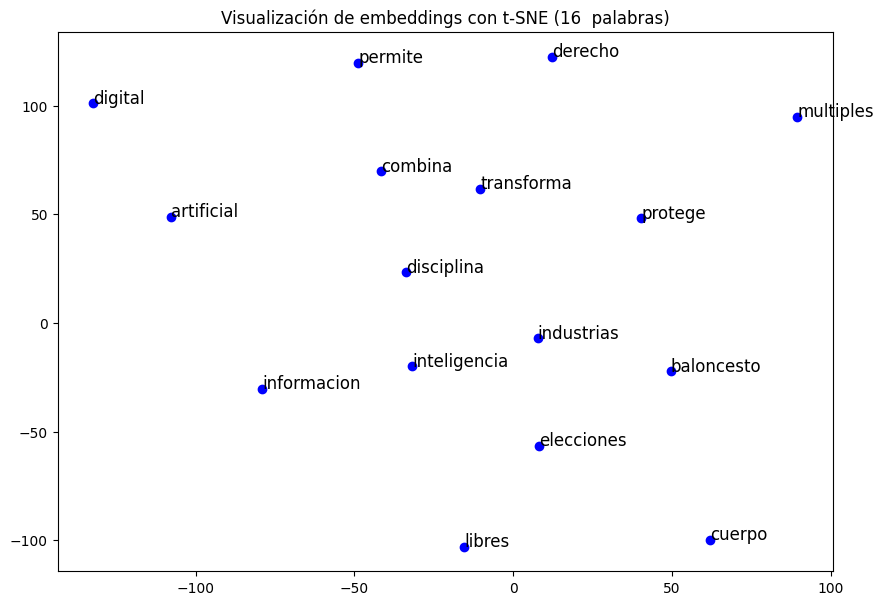

In [77]:
# Visualización
plt.figure(figsize=(10, 7))
for i, palabra in enumerate(palabras_filtradas):
    x, y = X_2d[i, 0], X_2d[i, 1]
    plt.scatter(x, y, c="blue")
    plt.text(x+0.05, y+0.05, palabra, fontsize=12)

# Solo las 16  palabras más comunes en el documento
plt.title("Visualización de embeddings con t-SNE (16  palabras)")
plt.show()

## 1.	¿Cuántos dominios o grupos de datos puedes identificar visualmente en la gráfica?

Se puede observar que existen 4 grupos o dominios





## 2.	¿Cuáles son esos dominios?

* Dominio 1, las palabras: `inteligencia, artificial, digital, informacion`. Relacionadas con términos de tecnología.
* Dominio 2, las palabras: `disciplina, combina, transforma, industrias`. Relacionadas con términos de la industria.
* Dominio 3, las palabras: `derecho, permite, elecciones, libres, protege`. Relacionadas con Política o la Sociedad.
* Dominio 4, las palabras: `baloncesto, cuerpo`. Relativas al deporte.